First 5 Rows:

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       -------------- 

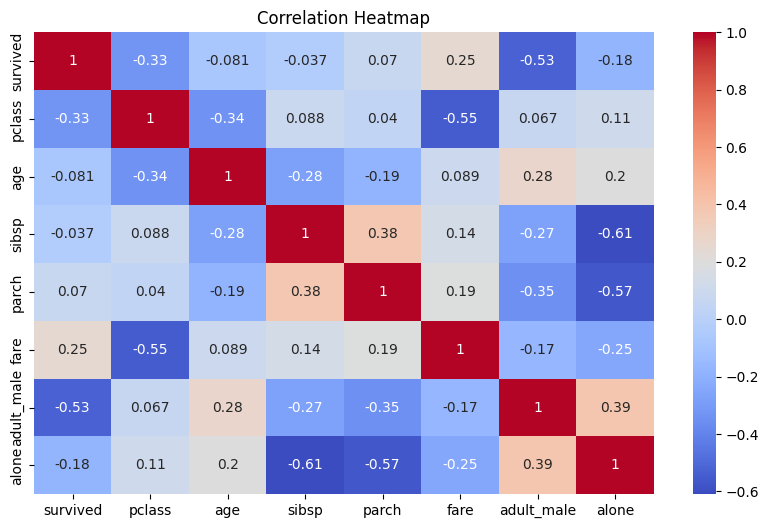

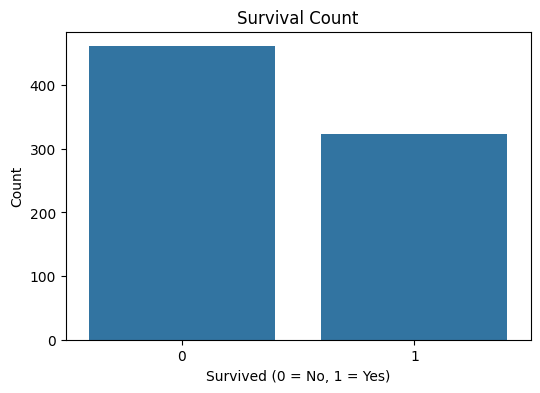

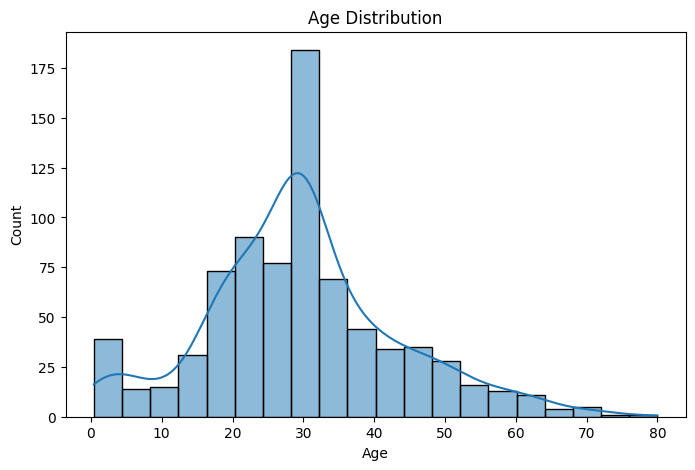

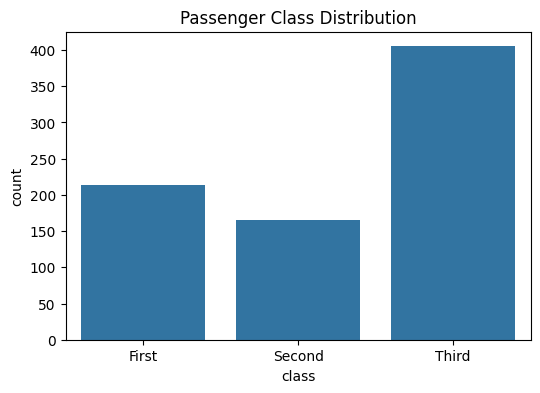

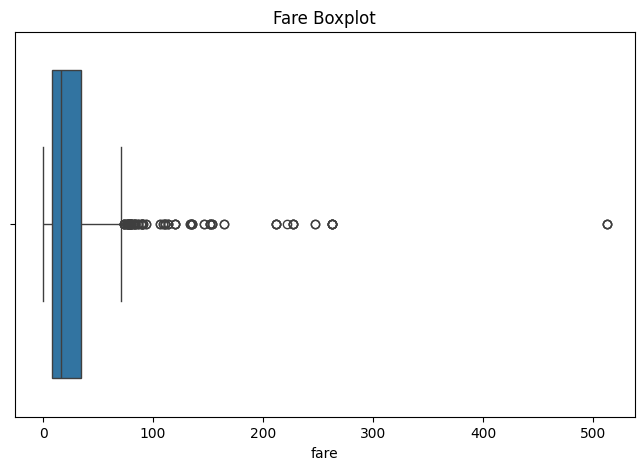

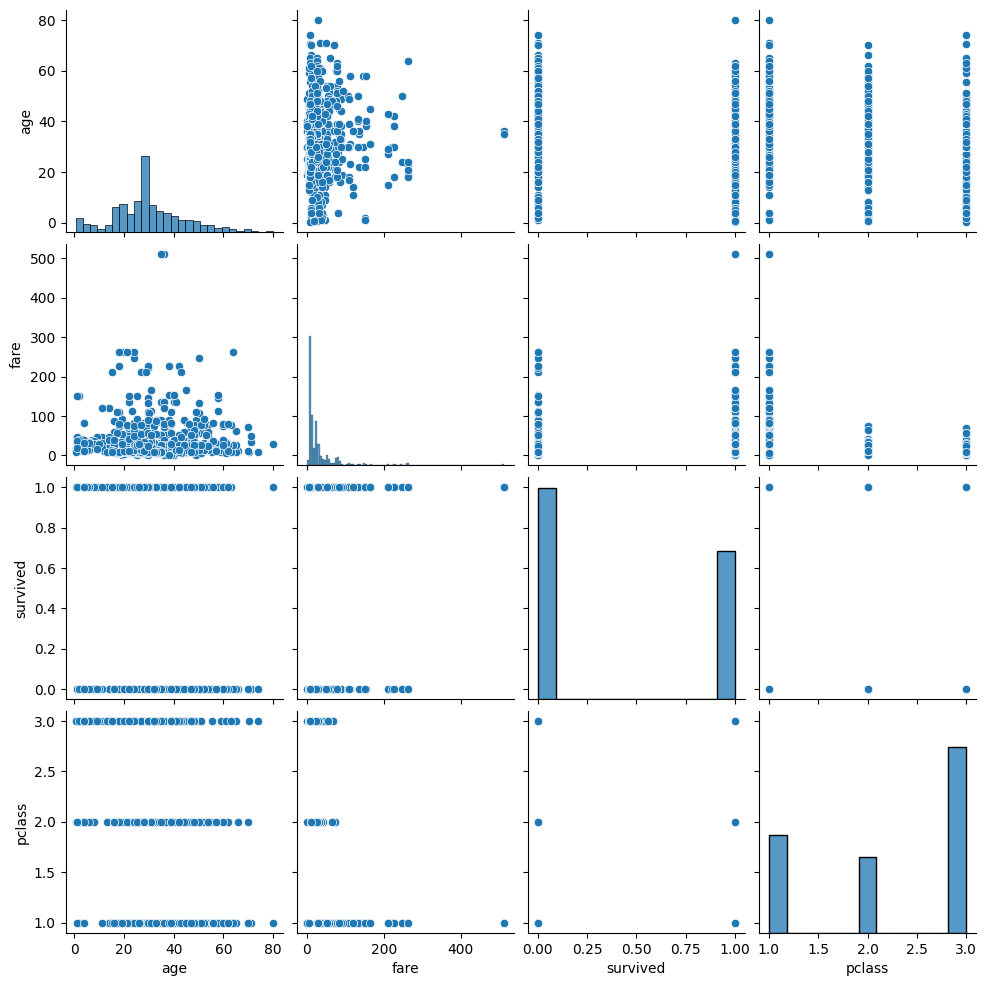


========== KEY INSIGHTS ==========
1. Higher class passengers had better survival rates.
2. Fare and passenger class show correlation.
3. Age distribution indicates most passengers were adults.
4. Some outliers exist in fare values.

EDA Project Completed Successfully


In [1]:
# ============================================
# Exploratory Data Analysis (EDA) Project
# Using Built-in Dataset
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Load Built-in Dataset
# ============================================

# Titanic dataset from seaborn
df = sns.load_dataset('titanic')

# ============================================
# 1. Basic Information
# ============================================

print("First 5 Rows:\n")
print(df.head())

print("\nDataset Information:\n")
print(df.info())

print("\nStatistical Summary:\n")
print(df.describe())

# ============================================
# 2. Missing Values
# ============================================

print("\nMissing Values:\n")
print(df.isnull().sum())

# Fill numerical missing values with mean
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicates
df = df.drop_duplicates()

print("\nData Cleaning Completed")

# ============================================
# 3. Correlation Heatmap
# ============================================

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# ============================================
# 4. Survival Count
# ============================================

plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

# ============================================
# 5. Age Distribution
# ============================================

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

# ============================================
# 6. Passenger Class Distribution
# ============================================

plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df)

plt.title("Passenger Class Distribution")

plt.show()

# ============================================
# 7. Boxplot for Fare
# ============================================

plt.figure(figsize=(8,5))
sns.boxplot(x=df['fare'])

plt.title("Fare Boxplot")

plt.show()

# ============================================
# 8. Pairplot
# ============================================

sns.pairplot(df[['age', 'fare', 'survived', 'pclass']])
plt.show()

# ============================================
# 9. Key Insights
# ============================================

print("\n========== KEY INSIGHTS ==========")

print("1. Higher class passengers had better survival rates.")
print("2. Fare and passenger class show correlation.")
print("3. Age distribution indicates most passengers were adults.")
print("4. Some outliers exist in fare values.")

print("\nEDA Project Completed Successfully")